# The Bona-Smith system in 2D with OpenMP: a solitary wave in a channel with a cylinder

We solve the Bona-Smith system of Boussinesq equations in two space dimensions,

$$\begin{aligned}
\eta_t + \nabla\cdot u + \nabla\cdot(\eta u) - b\,\Delta\eta_t &= 0,\\
u_t + \nabla\eta + \tfrac{1}{2}\nabla|u|^2 + c\,\nabla\Delta\eta - b\,\nabla(\nabla\cdot u_t) &= 0,
\end{aligned} \qquad b = \frac{3\theta^2 - 1}{6}, \quad c = \frac{2 - 3\theta^2}{3},$$

for the free surface elevation $\eta$ and the horizontal velocity $u = (u_1, u_2)$, with $\theta^2 = 9/11$, that is $b = 8/33$ and $c = -5/33$. For an irrotational flow $\nabla(\nabla\cdot u_t) = \Delta u_t$, as in `example6`. The system, its well-posedness on a plane domain and this finite element method are studied in the reference below. The domain is the channel $(-15, 20) \times (-6, 6)$ of `example6` with a cylinder of radius 1 at $(4, 0)$ removed, and all the walls reflect the waves, $u\cdot n = 0$ and $\nabla\eta\cdot n = 0$.

For these $b$ and $c$ the system has the exact line solitary wave of `example4`,

$$\eta(x, t) = \mathrm{sech}^2\left(\lambda\,(x - x_0 - c_s t)\right), \qquad u = \left(\tfrac{\sqrt{3}}{2}\,\eta,\ 0\right), \qquad \lambda = \frac{\sqrt{165}}{20}, \quad c_s = \frac{5\sqrt{3}}{6},$$

which we start at $x_0 = -5$. It reaches the cylinder at about $t = 5$ and the right wall at about $t = 17$.

**The weak form.** We multiply the first equation by a test function $\phi$ and the second by a vector test function $\psi$ with $\psi\cdot n = 0$ on the walls, and integrate by parts. Every boundary term contains $u\cdot n$, $\nabla\eta\cdot n$ or $\psi\cdot n$ and vanishes, so

$$\begin{aligned}
\int \left(\eta_t\,\phi + b\,\nabla\eta_t\cdot\nabla\phi\right) dx &= \int (1 + \eta)\,u\cdot\nabla\phi \, dx,\\
\int \left(u_t\cdot\psi + b\,(\nabla\cdot u_t)(\nabla\cdot\psi)\right) dx &= \int \left(\eta + \tfrac{1}{2}|u|^2 + c\,\Delta\eta\right) \nabla\cdot\psi \, dx.
\end{aligned}$$

**The discrete Laplacian.** The third derivative $c\,\nabla\Delta\eta$ has become $c\,\Delta\eta$ in the right-hand side, and $\eta$ is a $P_1$ function, whose Laplacian is zero in every element. We replace it by the discrete Laplacian $\Delta_h\eta \in Q$, defined by

$$\left(\Delta_h\eta, \phi\right) = -\left(\nabla\eta, \nabla\phi\right) \qquad \text{for every } \phi \in Q,$$

which is the weak Laplacian with the natural condition $\nabla\eta\cdot n = 0$. It costs one solve with the mass matrix of $Q$ at every evaluation of the right-hand side. As in `example6`, the discrete problem is a system $M\,c'(t) = f(c)$ of ordinary differential equations.

**OpenMP.** Build FEMd with OpenMP as in `example7`, `pip install . -C cmake.define.FEMD_OPENMP=ON` (on macOS after `brew install libomp`). The first cell puts NumPy's linear algebra on one thread and gives FEMd all the cores. Without OpenMP the notebook runs the same, on one thread.

**Reference.** V. A. Dougalis, D. E. Mitsotakis and J.-C. Saut, *Initial-boundary-value problems for Boussinesq systems of Bona-Smith type on a plane domain: theory and numerical analysis*, J. Sci. Comput. 44 (2010), 109–135, [DOI:10.1007/s10915-010-9368-z](https://doi.org/10.1007/s10915-010-9368-z) ([PDF](https://arxiv.org/abs/0907.4918)).

In [1]:
import os
for var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(var, "1")                 # NumPy's libraries on one thread, FEMd sets its own count

import time
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, div, dx

ncores = os.cpu_count() if fd.has_openmp() else 1
fd.set_num_threads(ncores)
print("OpenMP:", fd.has_openmp(), "  threads:", fd.get_num_threads(), "  loops go parallel above", fd.omp_threshold())

OpenMP: True   threads: 11   loops go parallel above 4096


**Mesh and spaces.** As in `example6`: the outer boundary gets the marker 1 and the cylinder the marker 2, $P_1$ elements for $\eta$ and $P_1$ elements for each component of $u$ with $u\cdot n = 0$ built in on both.

In [2]:
theta2 = 9 / 11
b, c = (3 * theta2 - 1) / 6, (2 - 3 * theta2) / 3          # 8/33 and -5/33

channel = [(-15, -6), (20, -6), (20, 6), (-15, 6)]
m = fd.triangulate(channel, holes=[fd.circle(4, 0, 1.0, 48)], max_edge=0.3, min_angle=28)

Q = fd.LagrangeSpace(m, 1)                          # eta, P1
V = fd.VectorFunctionSpace(m, 1, slip=[1, 2])       # u, P1, u.n = 0 on every wall
W = fd.ProductSpace(Q, V)
(e, u), (phi, psi) = fd.TrialFunctions(W), fd.TestFunctions(W)
print(m.ntriangles, "triangles,", W.dim, "unknowns")

23635 triangles, 35695 unknowns


**The forms.** `M` is the left-hand side. The right-hand side `F` reads the solution `w`, unpacked as `eta, vel`, and the discrete Laplacian `lap`, a Function of $Q$. The function `f` evaluates it: it puts the state into `w`, computes `lap` by one solve with the factored mass matrix of $Q$, and assembles `F`. The initial condition is the $L^2$ projection of the solitary wave.

In [3]:
M = fd.form((e * phi + b * dot(grad(e), grad(phi)) + dot(u, psi) + b * div(u) * div(psi)) * dx)

w = fd.Function(W)
eta, vel = w
lap = fd.Function(Q, "lap")
F = fd.form((dot((1 + eta) * vel, grad(phi)) + (eta + 0.5 * dot(vel, vel) + c * lap) * div(psi)) * dx)

q, chi = fd.TrialFunction(Q), fd.TestFunction(Q)
massQ = fd.form(q * chi * dx).assemble().solver()               # factored once
K = fd.form(dot(grad(q), grad(chi)) * dx).assemble()            # the stiffness matrix of Q

def f(U):
    w.vector[:] = U
    massQ.solve(-(K @ W.split(U)[0]), into=lap)                 # (lap, chi) = -(grad eta, grad chi)
    return F.assemble()

lam, cs, x0 = np.sqrt(165) / 20, 5 * np.sqrt(3) / 6, -5.0
eta0 = fd.sech(lam * (fd.x - x0))**2
w.project([eta0, fd.as_vector([np.sqrt(3) / 2 * eta0, 0])])
w_start = w.vector.copy()

**The run**, up to $T = 20$ with RK4 and $\Delta t = 0.05$. Each stage is one evaluation of `f`, an assembly of `F` on all threads and two solves with factored matrices. At $t = 4$ the wave has not reached the cylinder, so we compare $\eta$ along the centerline with the exact solitary wave there. We keep $\eta$ at $t = 0, 5, 10, 15, 20$ and check the mass $\int \eta\,dx$ at the end.

In [4]:
dt, T = 0.05, 20.0
rk = fd.ERK(M, f, dt, "rk4")
mass = fd.form(eta * dx)
mass0 = mass.assemble()

snapshots = {0.0: w.split()[0].vector.copy()}
t0 = time.perf_counter()
for n in range(1, round(T / dt) + 1):
    rk.step(w)
    if n == 80:
        pts = np.column_stack([np.linspace(-15, 1, 321), np.zeros(321)])
        exact = 1 / np.cosh(lam * (pts[:, 0] - x0 - cs * rk.t))**2
        print(f"t = {rk.t:g}: max error in eta on the centerline {np.max(np.abs(w.split()[0].at(pts) - exact)):.2e}")
    if n % 100 == 0:
        snapshots[rk.t] = w.split()[0].vector.copy()
print(f"{time.perf_counter() - t0:.0f} s for {round(T / dt)} steps, change in mass {abs(mass.assemble() - mass0):.1e}")

t = 4: max error in eta on the centerline 4.69e-03
14 s for 400 steps, change in mass 2.1e-14


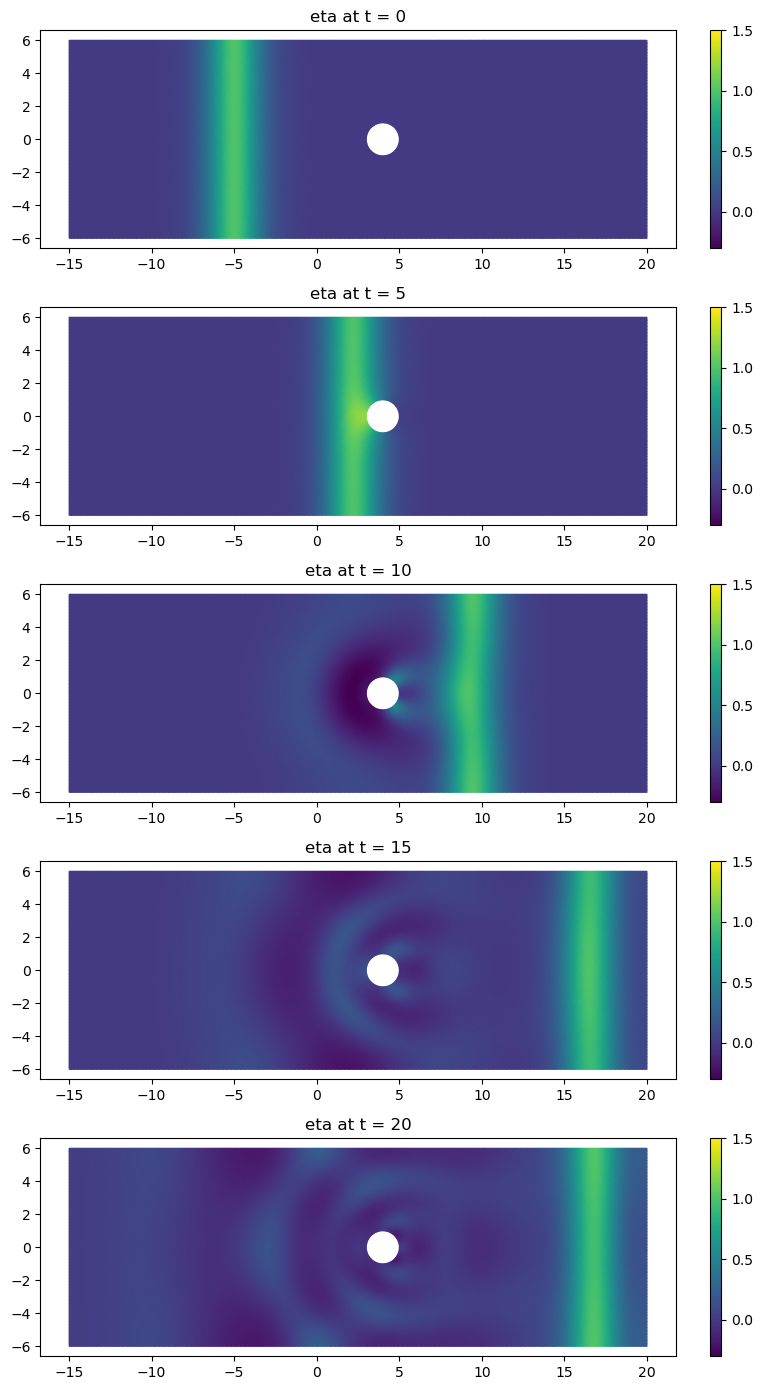

In [5]:
fig, axs = plt.subplots(len(snapshots), 1, figsize=(9, 2.8 * len(snapshots)))
for ax, (t, coeffs) in zip(axs, snapshots.items()):
    fd.Function(Q, "eta", coeffs).plot(ax, cmap="viridis", vmin=-0.3, vmax=1.5)
    ax.set_title(f"eta at t = {t:g}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()